In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [4]:
data = pd.merge(ratings, movies, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


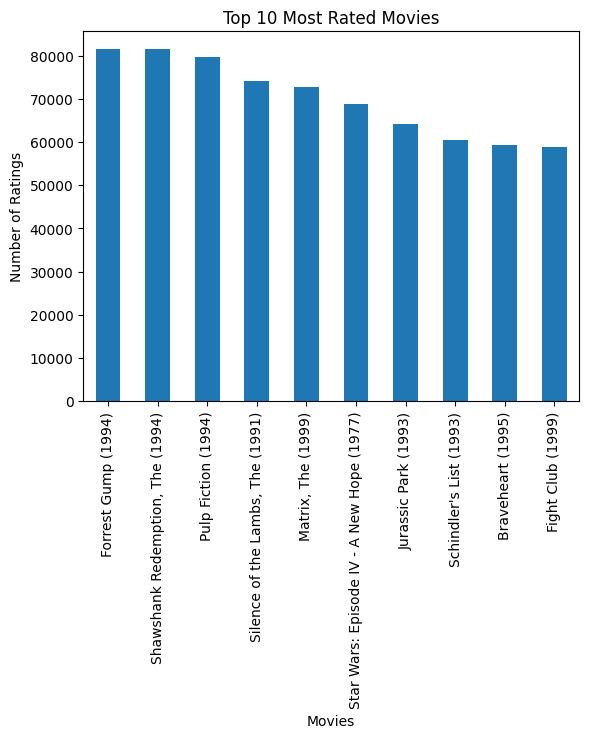

In [5]:
top_movies = data['title'].value_counts().head(10)

top_movies.plot(kind='bar')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movies")
plt.ylabel("Number of Ratings")
plt.show()

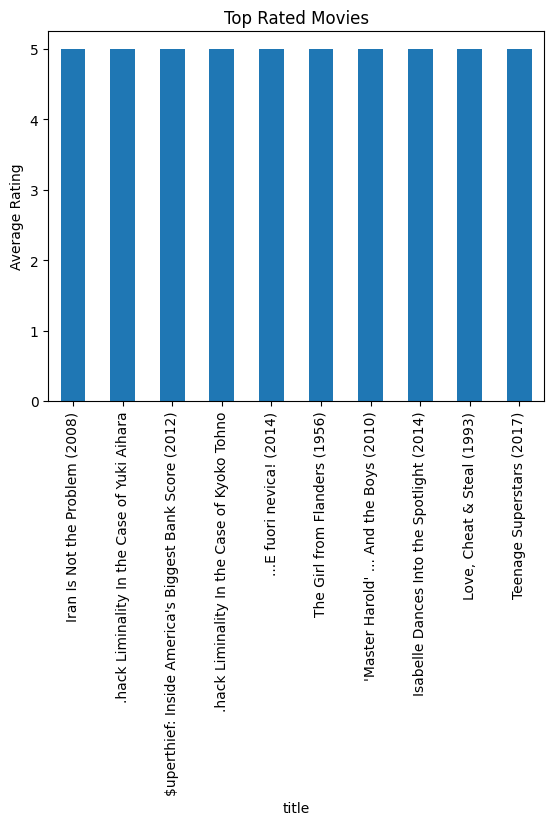

In [6]:
avg_rating = data.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

avg_rating.plot(kind='bar')

plt.title("Top Rated Movies")
plt.ylabel("Average Rating")
plt.show()

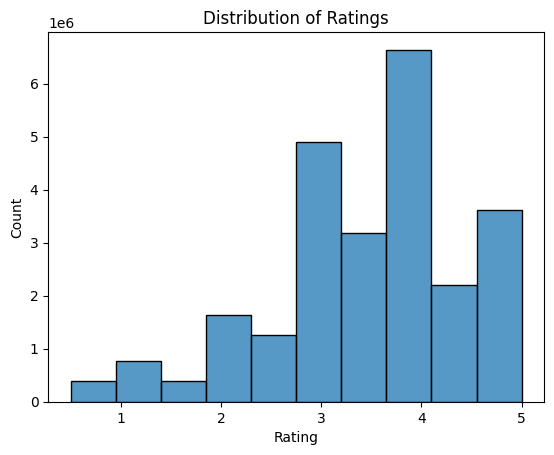

In [7]:
sns.histplot(data['rating'], bins=10)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.show()

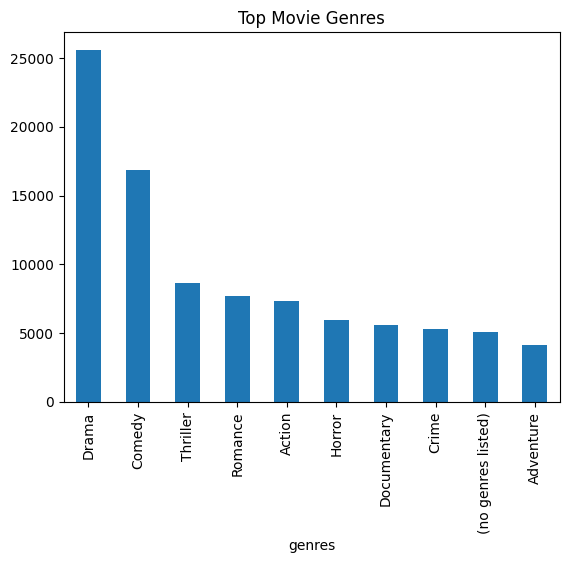

In [8]:
genre_counts = movies['genres'].str.split('|').explode().value_counts().head(10)

genre_counts.plot(kind='bar')

plt.title("Top Movie Genres")
plt.show()

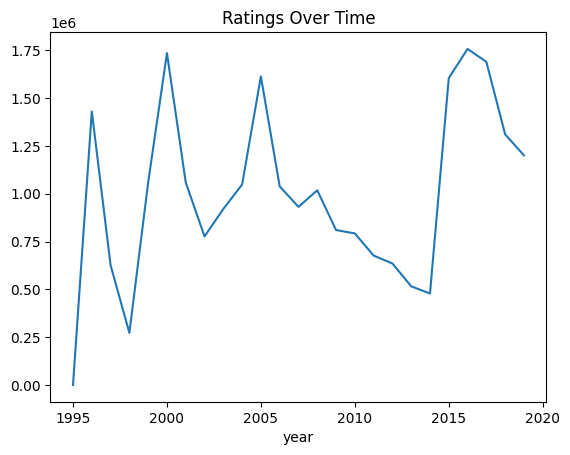

In [9]:
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
data['year'] = data['timestamp'].dt.year

data['year'].value_counts().sort_index().plot()

plt.title("Ratings Over Time")
plt.show()